|   |   |
|---|---|
| **Materia:** | IAAA1 - Aprendizaje Automático 1. |
| **Trabajo:** | TP1 - Comparación de métodos de escalamiento con Scikit-Learn. |
| **Docente:** | Ana Diedrichs. |
| **Alumno:** | Nicolás Druetta. |
| **DNI:** | 36.604.286. |
######

# Compararemos el efecto de distintos escaladores sobre datos con valores atípicos.

La característica 0 (ingreso mediano en un bloque) y la característica 5 (ocupación promedio de la vivienda) del
`california_housing_dataset` tienen escalas muy
diferentes y contienen algunos valores atípicos muy grandes. Estas dos
características generan dificultades para visualizar los datos y, más
importante aún, pueden degradar el rendimiento predictivo de muchos algoritmos de
aprendizaje automático. Los datos sin escalar también pueden ralentizar o incluso impedir la
convergencia de muchos algoritmos basados en gradiente.

De hecho, muchos de los estimadores que se usan en la práctica (como redes neuronales,
máquinas de vectores de soporte y regresión lineal con regularización L1 o L2)
suponen que todas las características están centradas alrededor de 0 y tienen una
varianza del mismo orden. Como alternativa, se puede usar el *rescaling*
(característica por característica) o el *normalizing* (muestra por muestra) para lograr un resultado
parecido que haga más sencillo el entrenamiento de un estimador.

Es importante recordar que los **escaladores**, **transformadores** y
**normalizadores** no son en absoluto equivalentes, y el ejemplo siguiente muestra
las principales diferencias entre algunos métodos populares de preprocesamiento de datos.

In [370]:
# Importamos las librerías necesarias.
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import cm

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

In [371]:
# Cargamos el dataset de viviendas de California.
dataset = fetch_california_housing()

# Adicional: Convierto los datos a DataFrame de pandas para ver qué trae.
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

# Adicional: Muestro las primeras 5 filas.
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [372]:
# Adicional: Muestro un resumen estadístico de las columnas numéricas.
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [373]:
# Guardamos las variables predictoras y la variable objetivo del dataset.
X_full, y_full = dataset.data, dataset.target

# Guardamos los nombres de las columnas del dataset.
feature_names = dataset.feature_names

# Definimos un nombre más legible para cada una de las características.
feature_mapping = {
    "MedInc": "Ingreso mediano en el bloque",
    "HouseAge": "Edad mediana de la vivienda en el bloque",
    "AveRooms": "Cantidad promedio de habitaciones",
    "AveBedrms": "Cantidad promedio de dormitorios",
    "Population": "Población del bloque",
    "AveOccup": "Ocupación promedio de la vivienda",
    "Latitude": "Latitud del bloque de viviendas",
    "Longitude": "Longitud del bloque de viviendas",
}

# Tomamos solo 2 características para facilitar la visualización.
# La característica MedInc tiene una distribución de cola larga.
# La característica AveOccup tiene pocos valores atípicos, pero muy grandes.
features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]

In [374]:
# Definimos las distribuciones que vamos a representar.
distributions = [
    (
        "Datos sin escalar",
        X
    ),
    (
        "Datos después del escalado estándar",
        StandardScaler().fit_transform(X)
    ),
    (
        "Datos después del escalado min-max",
        MinMaxScaler().fit_transform(X)
    ),
    (
        "Datos después del escalado max-abs",
        MaxAbsScaler().fit_transform(X)),
    (
        "Datos después del escalado robusto",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Datos después de la transformación de potencia (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Datos después de la transformación de potencia (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Datos después de la transformación por cuantiles (pdf uniforme)",
        QuantileTransformer(output_distribution="uniform", random_state=42).fit_transform(X),
    ),
    (
        "Datos después de la transformación por cuantiles (pdf gaussiana)",
        QuantileTransformer(output_distribution="normal", random_state=42).fit_transform(X),
    ),
    (
        "Datos después de la normalización L2 por muestra",
        Normalizer().fit_transform(X)
    )
]

#### Adicional para mi:
- **StandardScaler:** expresa cada valor en cantidad de desvíos estándar respecto de la media.
- **MinMaxScaler:** lleva los valores a un rango fijo, normalmente entre 0 y 1.
- **MaxAbsScaler:** divide cada valor por el valor absoluto máximo de la variable, dejando el rango entre -1 y 1 si hay negativos, o entre 0 y 1 si todos son positivos.
- **RobustScaler:** expresa cada valor respecto de la mediana y del rango intercuartílico (IQR), reduciendo la influencia de los outliers.
- **PowerTransformer (Yeo-Johnson):** transforma la forma de la distribución para reducir asimetría y luego la estandariza.
- **PowerTransformer (Box-Cox):** transforma la distribución para acercarla a una normal y luego la estandariza, pero solo puede aplicarse a valores estrictamente positivos.
- **QuantileTransformer (pdf uniforme):** reubica los valores según su posición relativa y los reparte sobre una distribución uniforme, normalmente entre 0 y 1.
- **QuantileTransformer (pdf gaussiana):** reubica los valores según su posición relativa y los convierte en una distribución parecida a una normal.
- **Normalizer (L2 por muestra):** no reescala cada variable por separado, sino que reexpresa cada fila completa para que su vector tenga norma 1.

#### Diferencia clara:
- **Cuantiles** → concepto general. Divide los datos en partes iguales según percentiles.
- **Cuartiles** → caso particular de cuantiles. Divide en 4 partes:
  - Q1 = percentil 25
  - Q2 = percentil 50 (mediana)
  - Q3 = percentil 75

In [375]:
# Escalamos la salida entre 0 y 1 para la barra de color.
y = minmax_scale(y_full)

# ¡Cambio! Elijo otra parleta a gusto.
cmap = getattr(cm, "inferno", cm.hot_r)

In [376]:
# Función que crea los ejes de la figura.
def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # Definimos los ejes para el primer gráfico.
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # Definimos los ejes para el gráfico ampliado.
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # Definimos los ejes para la barra de color.
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )

In [377]:
# Función que grafica la distribución de los datos.
def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    # Definimos el título y las etiquetas.
    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # Graficamos la dispersión de puntos.
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Eliminamos el borde superior y el derecho por estética.
    # Dejamos una disposición prolija de los ejes.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Graficamos el histograma para el eje X1.
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color=cmap(0.6), ec=cmap(0.6)
    )
    hist_X1.axis("off")

    # Graficamos el histograma para el eje X0.
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color=cmap(0.6), ec=cmap(0.6)
    )
    hist_X0.axis("off")

In [378]:
# Función que muestra una transformación específica con la vista completa y el zoom.
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Datos completos",
    )

    # Aplicamos el zoom.
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom",
    )

    # Mostramos la barra de color.
    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Mapeo de color para los valores de y",
    )

## Datos originales

Cada transformación se representa mostrando dos características transformadas, con el
gráfico de la izquierda mostrando el conjunto de datos completo y el de la derecha ampliado para mostrar el
conjunto de datos sin los valores atípicos marginales. Una gran mayoría de las muestras queda
compactada en un rango específico, [0, 10] para el ingreso mediano y [0, 6] para la
ocupación promedio de la vivienda. Nótese que hay algunos valores atípicos marginales (algunos
bloques tienen una ocupación promedio superior a 1200). Por lo tanto, un preprocesamiento específico
puede resultar muy beneficioso. A continuación se muestran algunos ejemplos y se destacan las características
de algunos métodos de preprocesamiento en presencia de valores atípicos.

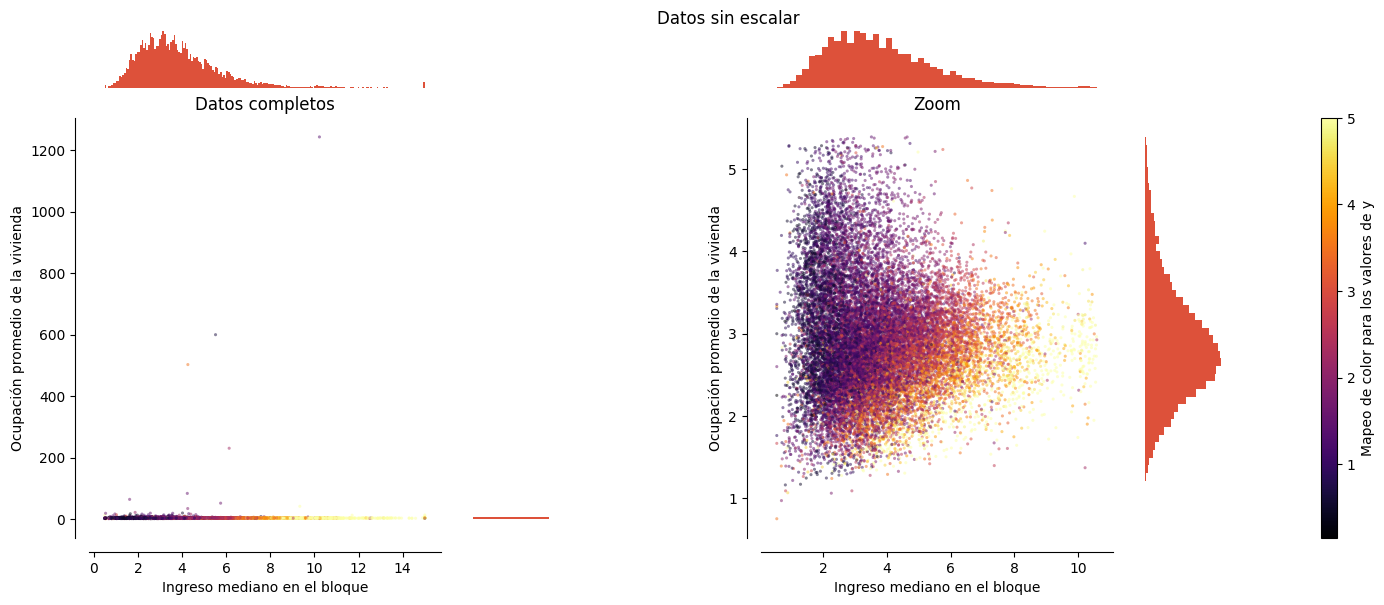

In [379]:
# Mostramos los datos originales.
make_plot(0)

## StandardScaler

`StandardScaler` elimina la media y escala
los datos a varianza unitaria. El escalado reduce el rango de los valores de las características, como se muestra en la figura de la izquierda de abajo.
Sin embargo, **los valores atípicos influyen al calcular la media empírica y la
desviación estándar**. Nótese, en particular, que como los valores atípicos de cada
característica tienen magnitudes diferentes, la dispersión de los datos transformados en
cada característica es muy diferente: la mayor parte de los datos se encuentra en el rango [-2, 4]
para la característica transformada de ingreso mediano, mientras que esos mismos datos quedan comprimidos en el rango más pequeño [-0.2, 0.2]
para la ocupación promedio de la vivienda transformada.

Por lo tanto, **`StandardScaler`
no puede garantizar escalas equilibradas entre características en presencia de valores atípicos.**

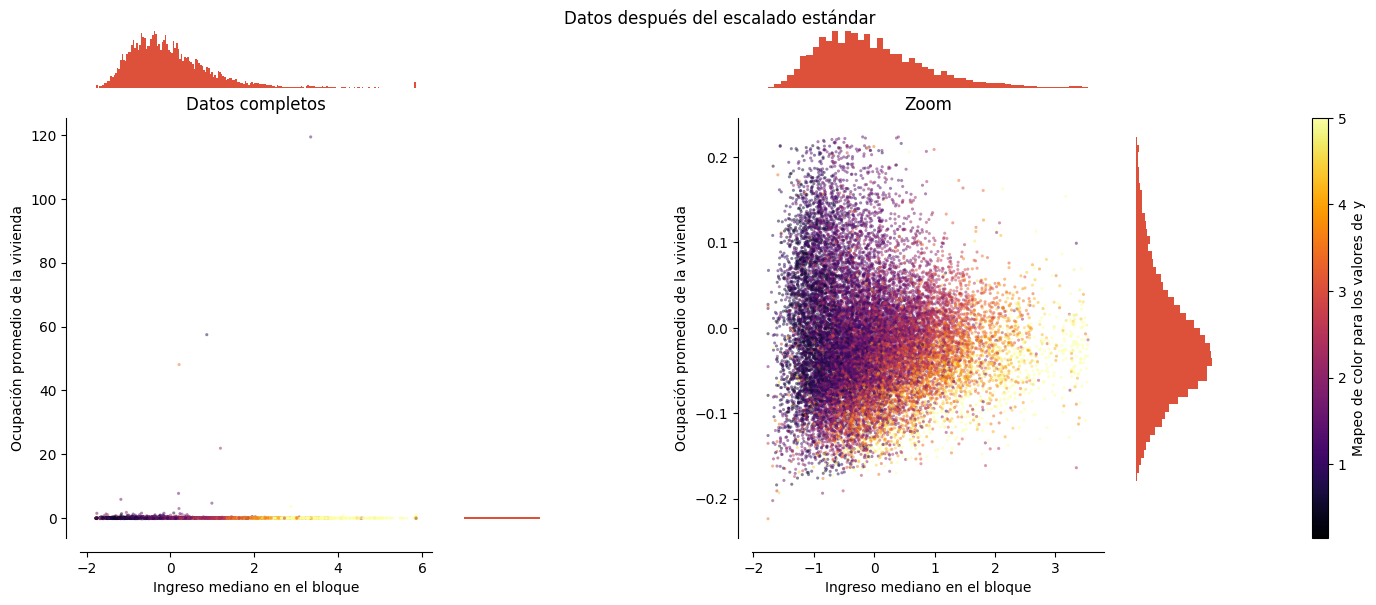

In [380]:
# Mostramos StandardScaler.
make_plot(1)

## MinMaxScaler

`MinMaxScaler` reescala el conjunto de datos de modo que
todos los valores de las características queden en
el rango [0, 1], como se muestra en el panel de la derecha de abajo. Sin embargo, este escalado
**comprime todos los valores no atípicos en el estrecho rango** [0, 0.005] para la
ocupación promedio transformada de la vivienda.

**Tanto `StandardScaler` como
`MinMaxScaler` son muy sensibles a la
presencia de valores atípicos.**

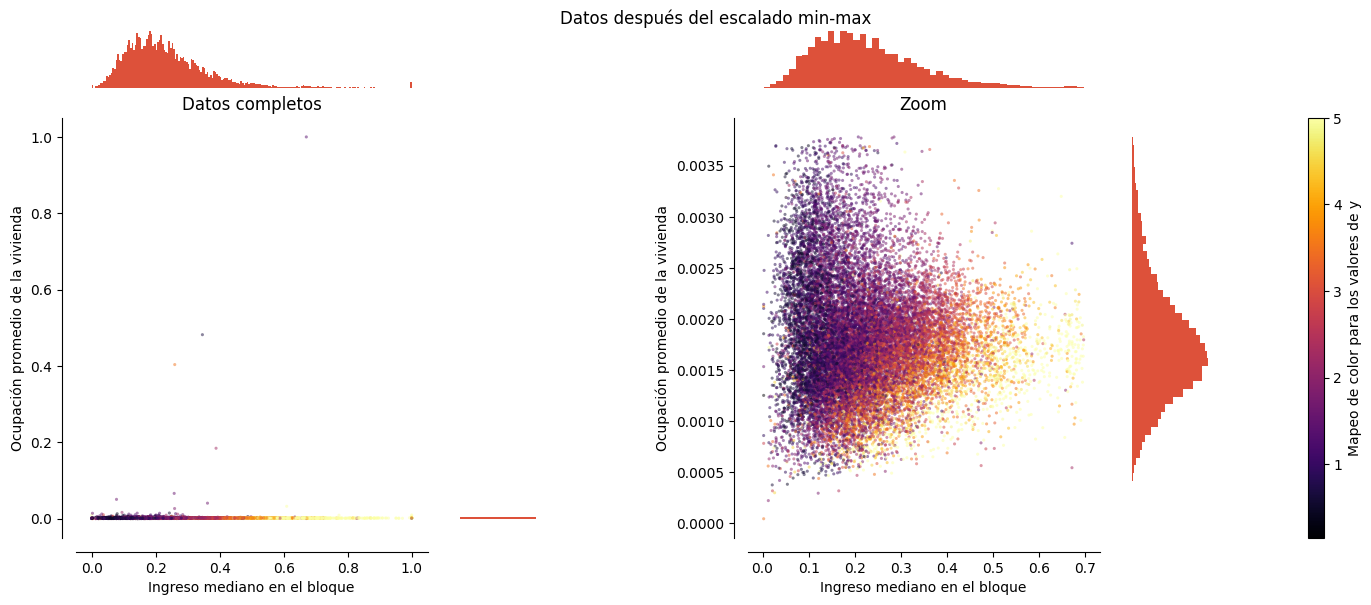

In [381]:
# Mostramos MinMaxScaler.
make_plot(2)

## MaxAbsScaler

`MaxAbsScaler` es similar a
`MinMaxScaler`, excepto que los
valores se mapean en varios rangos dependiendo de si hay valores negativos
o positivos presentes. Si solo hay valores positivos, el
rango es [0, 1]. Si solo hay valores negativos, el rango es [-1, 0].
Si hay valores negativos y positivos, el rango es [-1, 1].
En datos únicamente positivos, **tanto `MinMaxScaler`
como `MaxAbsScaler` se comportan de manera similar** y, por lo tanto,
**`MaxAbsScaler` también sufre la presencia de valores atípicos grandes.**

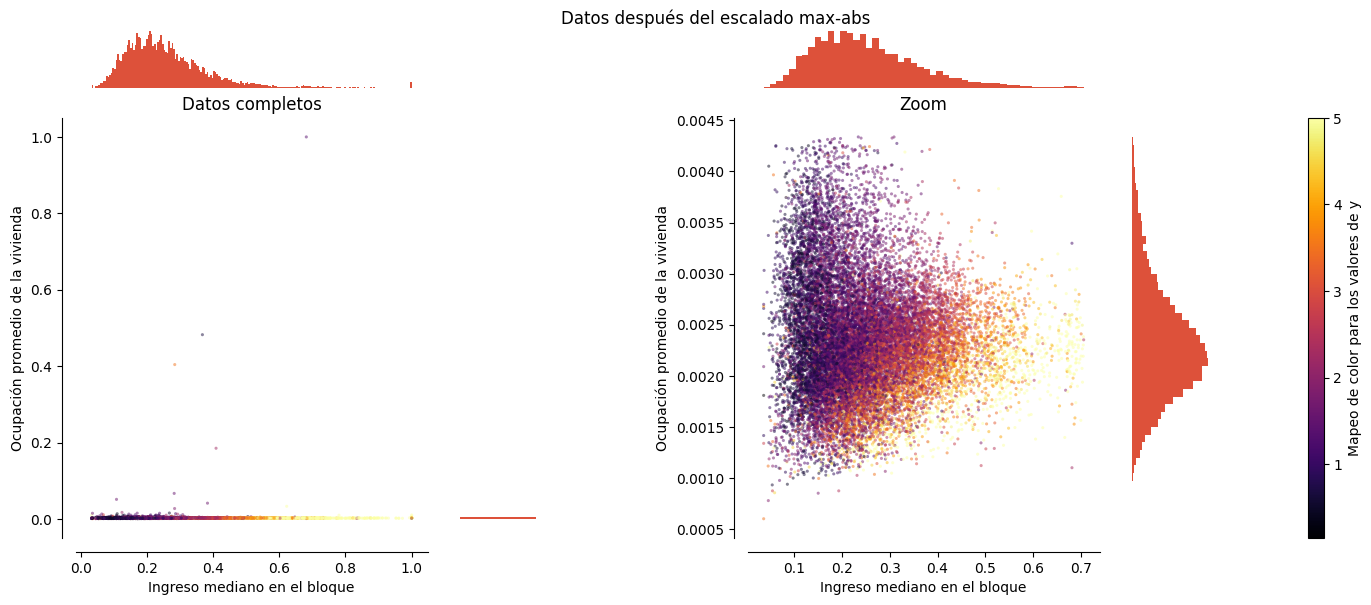

In [382]:
# Mostramos MaxAbsScaler.
make_plot(3)

## RobustScaler

A diferencia de los escaladores anteriores, las estadísticas de centrado y escalado de
`RobustScaler`
se basan en percentiles y, por lo tanto, **no se ven influidas por una pequeña
cantidad de valores atípicos marginales muy grandes**. En consecuencia, el rango resultante de
los valores transformados de las características es mayor que para los escaladores anteriores y,
lo que es más importante, es aproximadamente similar: para ambas características, la mayoría de
los valores transformados quedan en un rango [-2, 3], como se observa en la figura ampliada.
Nótese que los propios valores atípicos siguen estando presentes en los datos transformados. Si se desea un recorte
separado de los valores atípicos, se requiere una transformación no lineal.

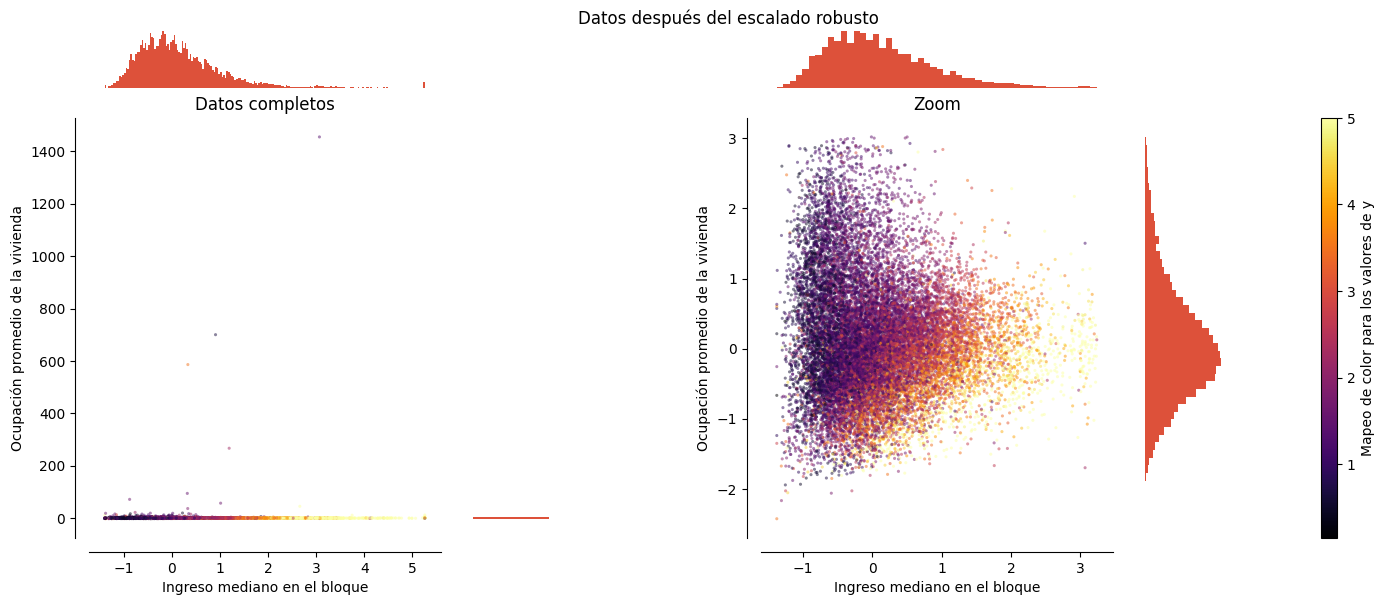

In [383]:
# Mostramos RobustScaler.
make_plot(4)

## PowerTransformer

**`PowerTransformer` aplica una transformación
de potencia a cada característica para hacer que los datos se parezcan más a una distribución gaussiana** con el fin de
estabilizar la varianza y minimizar la asimetría. Actualmente se admiten las transformaciones Yeo-Johnson
y Box-Cox, y el factor óptimo de escalado
se determina mediante estimación de máxima verosimilitud en ambos
métodos. De manera predeterminada, `PowerTransformer` aplica
normalización a media cero y varianza unitaria. Nótese que
Box-Cox solo puede aplicarse a datos estrictamente positivos. Aquí se pueden usar
Yeo-Johnson y Box-Cox porque las características elegidas son positivas.

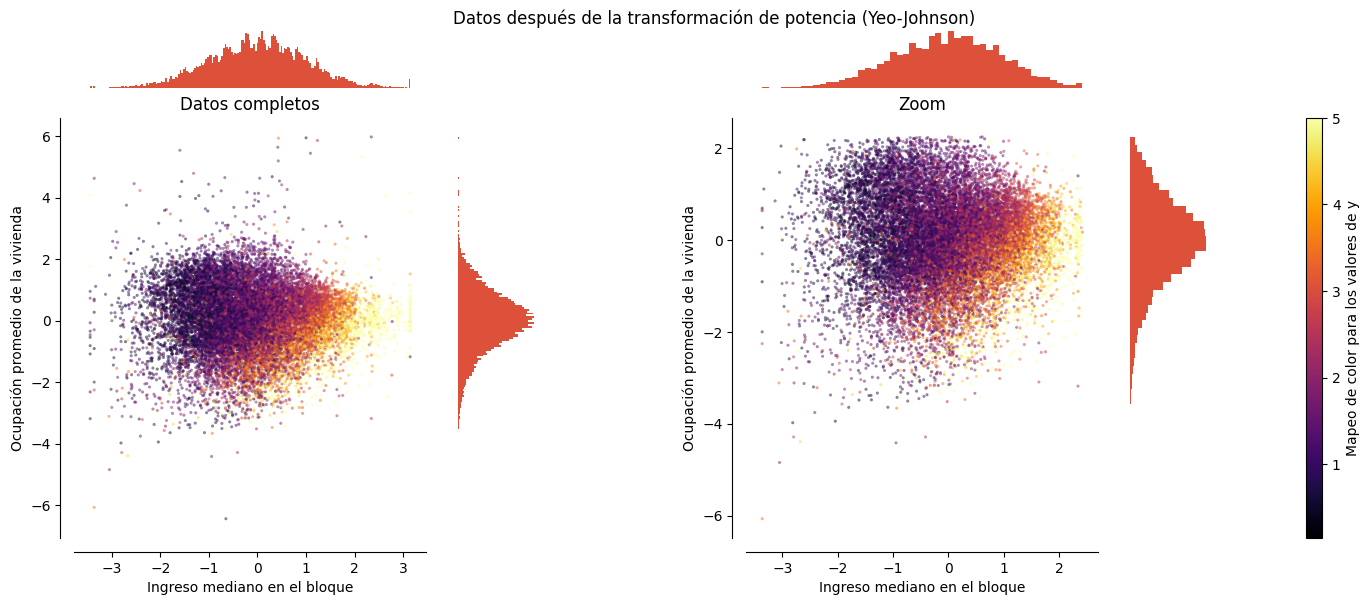

In [384]:
# Mostramos PowerTransformer (Yeo-Johnson).
make_plot(5)

#### Adicional: Cómo funciona PowerTransformer.

**Aplica una transformación matemática de potencia a cada columna.**

Algo como:

- logaritmos,
- raíces,
- potencias con un exponente especial.

Ese exponente no lo elegimos nosotros. El método lo estima automáticamente buscando cuál transforma mejor los datos.

Es lo que el texto original llama: “el factor óptimo de escalado se determina mediante estimación de máxima verosimilitud”.

O sea:

- prueba internamente qué parámetro conviene,
- y elige el que deja la variable más cercana a una distribución gaussiana.

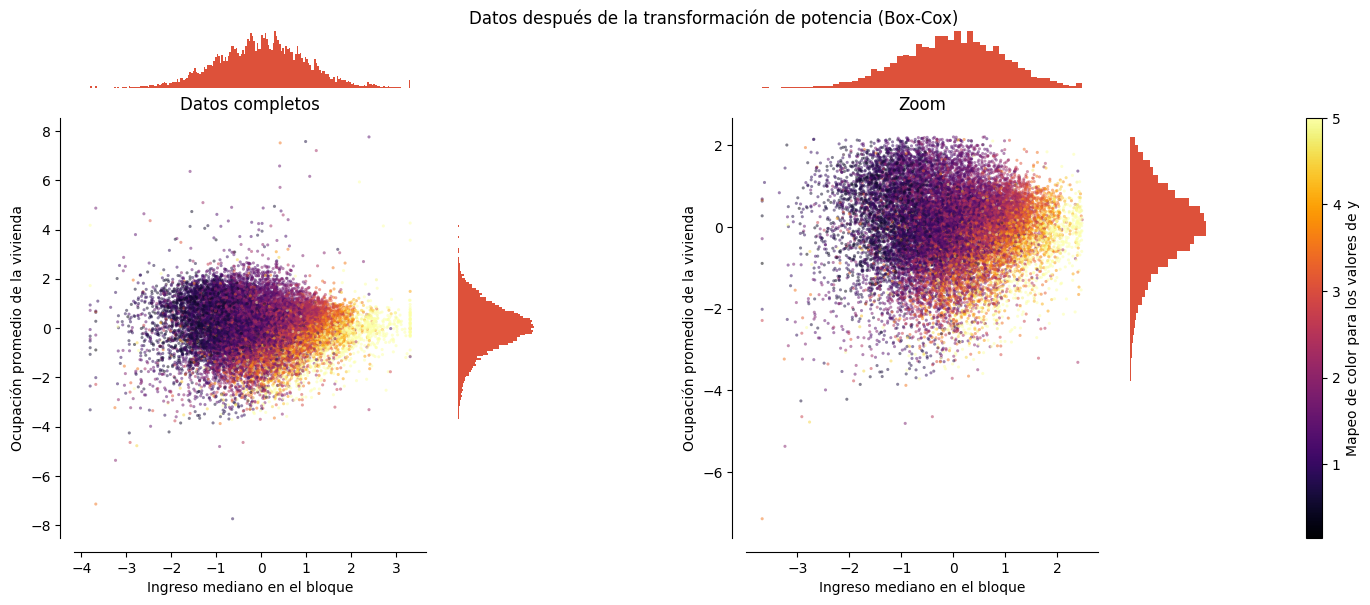

In [385]:
# Mostramos PowerTransformer (Box-Cox).
make_plot(6)

## QuantileTransformer (salida uniforme)

`QuantileTransformer` aplica una transformación no lineal de modo que la
función de densidad de probabilidad de cada característica se mapeará a una distribución uniforme
o gaussiana. En este caso, todos los datos, incluidos los valores atípicos,
se mapearán a una distribución uniforme con el rango [0, 1], haciendo que los
valores atípicos sean indistinguibles de los no atípicos.

**`RobustScaler` y
`QuantileTransformer` son robustos frente a valores atípicos** en el sentido de que
agregar o quitar valores atípicos en el conjunto de entrenamiento producirá aproximadamente
la misma transformación. Sin embargo, a diferencia de `RobustScaler`,
**`QuantileTransformer` también colapsará automáticamente cualquier valor atípico** al
configurarlo en los límites a priori definidos del rango de salida ([0, 1]). Esto puede generar
artefactos de saturación para valores extremos.

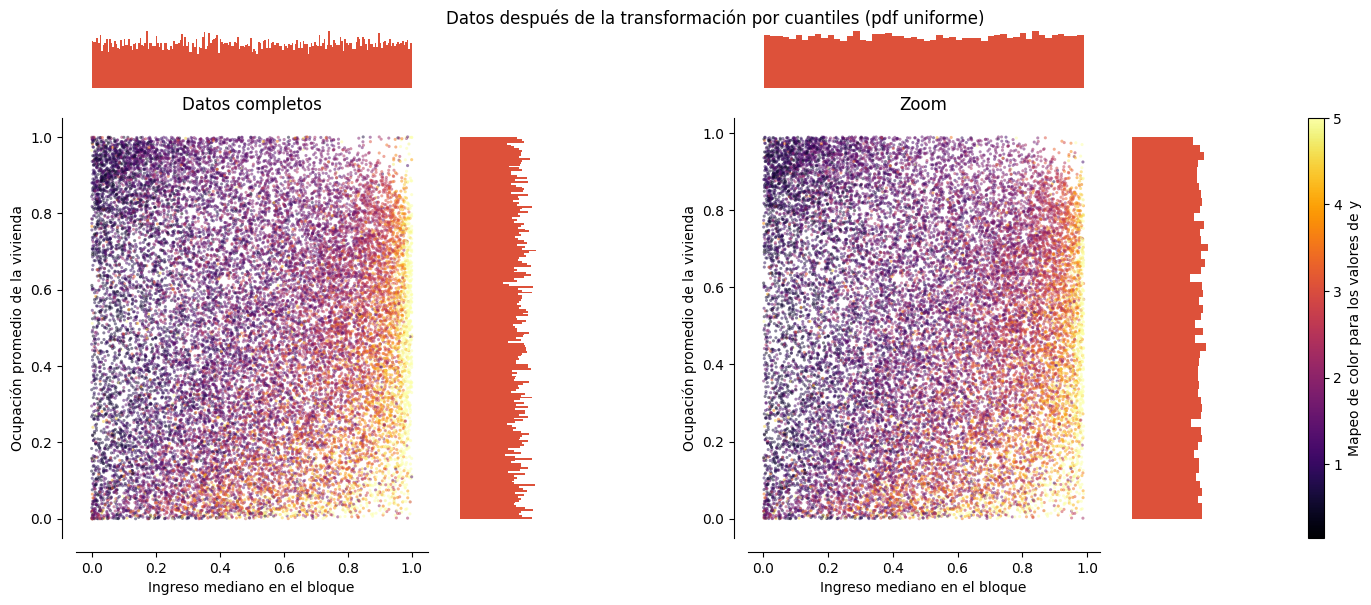

In [386]:
# Mostramos QuantileTransformer con salida uniforme.
make_plot(7)
# QuantileTransformer(output_distribution="uniform", random_state=42).fit_transform(X)

## QuantileTransformer (salida gaussiana)

Para mapear a una distribución gaussiana, establezco el parámetro
`output_distribution='normal'`.

Adicional: La transformación por cuantiles con salida gaussiana reubica los valores según su posición relativa en la distribución y los convierte a una escala con forma aproximadamente normal. Por eso aparecen valores negativos y positivos, centrados alrededor de 0, sin que representen los valores originales de las variables. **Esta técnica reduce el efecto de los outliers y produce distribuciones más simétricas.**

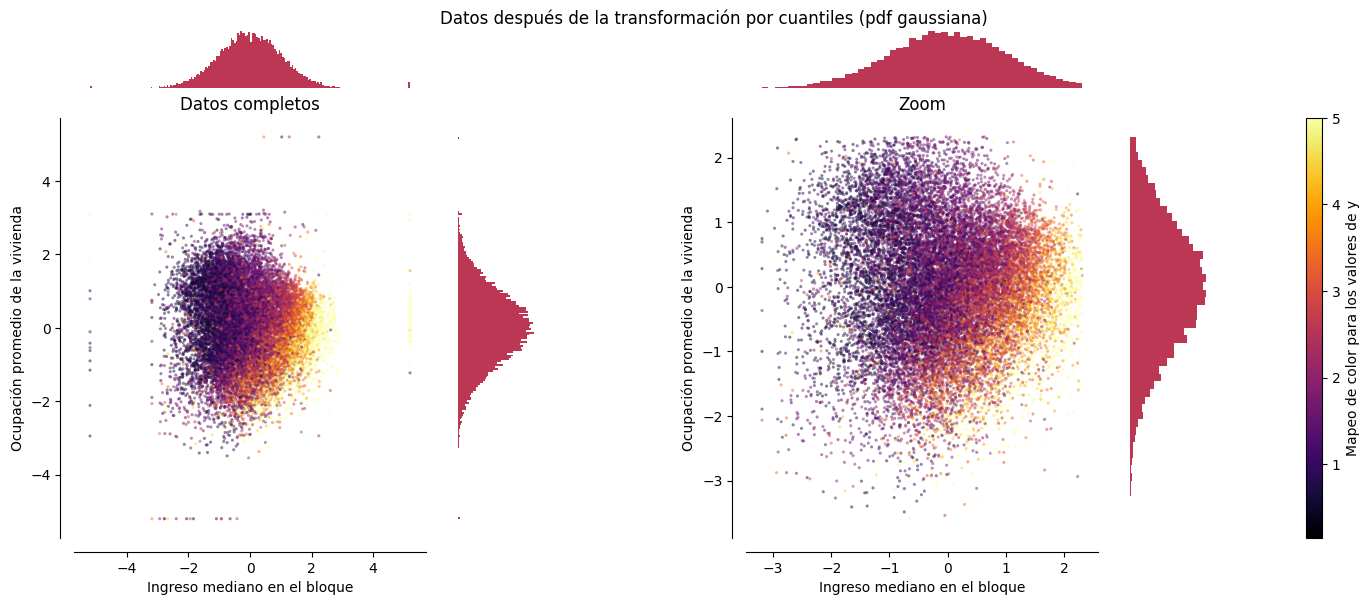

In [367]:
# Mostramos QuantileTransformer con salida gaussiana.
make_plot(8)
# QuantileTransformer(output_distribution="normal", random_state=42).fit_transform(X)

## Normalizer

**`Normalizer` reescala el vector de cada
muestra para que tenga norma unitaria**,
independientemente de la distribución de las muestras. Esto puede verse en ambas
figuras de abajo, donde todas las muestras se mapean sobre el círculo unitario. En nuestro
ejemplo, las dos características seleccionadas solo tienen valores positivos; por lo tanto, los
datos transformados quedan únicamente en el cuadrante positivo. Esto no ocurriría si algunas
características originales tuvieran una mezcla de valores positivos y negativos.

---
Adicional:

Con Normalizer:

- no estamos diciendo si un valor está por encima o por debajo de la media;
- no estamos diciendo si está cerca del mínimo o máximo;
- no estamos corrigiendo outliers como lo hacemos con RobustScaler.

Estamos diciendo:

**“Vamos a mirar cada fila como una combinación de proporciones.”**

Cuándo tiene sentido usarlo: Sirve mucho cuando importa la dirección del vector más que el tamaño.

Ejemplos típicos:

- texto y NLP;
- similitud coseno;
- datos donde importa la composición relativa;
- clustering o clasificación basada en orientación.

#### **La norma es el tamaño o la longitud de una fila vista como vector.**

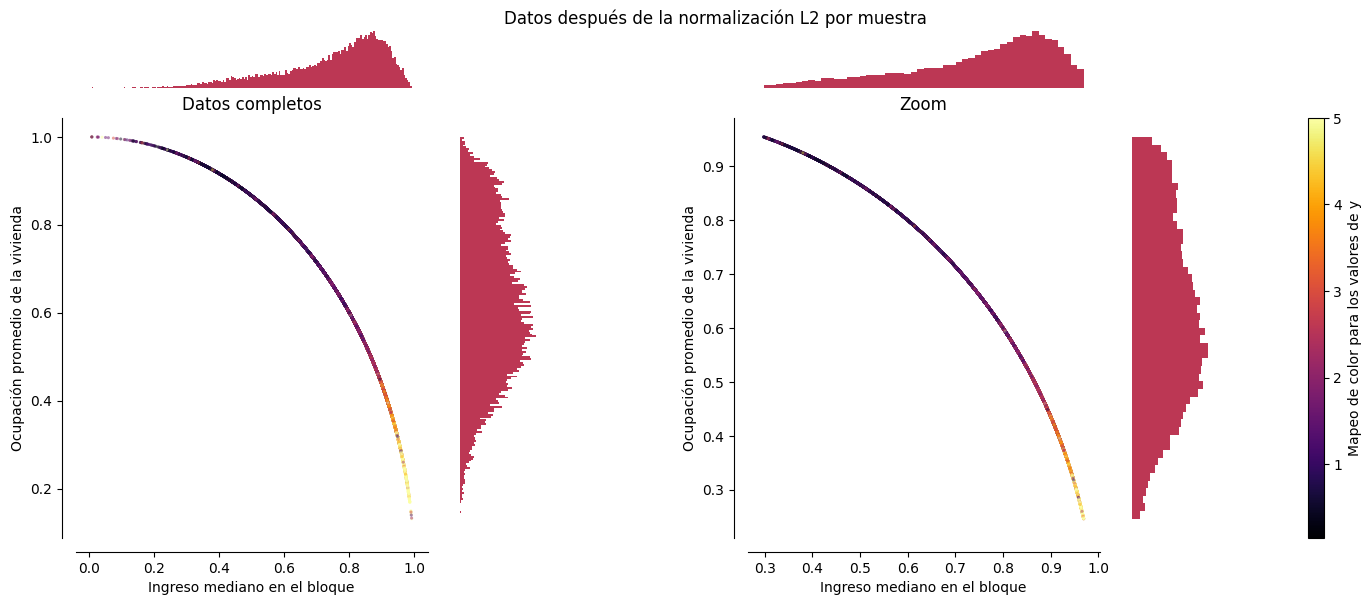

In [368]:
# Mostramos Normalizer.
make_plot(9)

Ejemplos de escalado lineal en tu TP.
MinMaxScaler
StandardScaler
MaxAbsScaler

Todos estos son lineales.

Qué significa eso en la práctica.
Si un valor era el doble que otro, lo sigue siendo después del escalado.
No corrige asimetría.
No cambia la forma de la nube de puntos (solo la estira o comprime).

In [369]:
# Mis conclusiones finales.
print("""
1. Sensibilidad a los valores atípicos.
En StandardScaler y MinMaxScaler, la masa principal de los datos queda comprimida cuando hay valores atípicos muy alejados.
Esto ocurre porque StandardScaler usa la media y el desvío estándar, y MinMaxScaler usa el mínimo y el máximo.
Por eso, ambos métodos pueden resultar poco adecuados en este caso, ya que los valores atípicos condicionan la escala
y hacen que la mayor parte de los datos quede demasiado concentrada.

2. Robustez.
RobustScaler mantiene mejor el zoom sobre la mayoría de los datos porque usa estadísticos robustos.
En lugar de la media y el desvío estándar, usa la mediana y el rango intercuartílico.
Los estadísticos que utiliza son los percentiles 25, 50 y 75, a partir de los cuales calcula el rango intercuartílico.

3. Normalización de la distribución.
PowerTransformer reduce la asimetría y acerca los datos a una distribución más normal, pero conserva mejor la estructura relativa.
QuantileTransformer con salida gaussiana fuerza más la forma normal y reubica los valores según su posición relativa.
Estas transformaciones pueden ser más útiles que un escalado lineal en modelos como regresión lineal,
regresión logística, redes neuronales y PCA.

4. El caso del Normalizer.
A diferencia de los otros métodos, que escalan columna por columna, Normalizer actúa por filas y transforma cada muestra completa.
Esto hace que todos los datos queden con el mismo tamaño y se pierdan las diferencias de escala.
Lo que se mantiene es la proporción entre las variables dentro de cada observación.
Un caso típico es el procesamiento de texto, donde interesa la composición de palabras y no la cantidad total.

5. Conclusión técnica.
Si estuviera entrenando un modelo de regresión lineal para predecir el precio de las casas
y notara que la variable ingreso medio tiene muchos valores atípicos, elegiría RobustScaler.
Porque limita el efecto de los valores extremos sin afectar demasiado al resto de los datos.
""")


1. Sensibilidad a los valores atípicos.
En StandardScaler y MinMaxScaler, la masa principal de los datos queda comprimida cuando hay valores atípicos muy alejados.
Esto ocurre porque StandardScaler usa la media y el desvío estándar, y MinMaxScaler usa el mínimo y el máximo.
Por eso, ambos métodos pueden resultar poco adecuados en este caso, ya que los valores atípicos condicionan la escala 
y hacen que la mayor parte de los datos quede demasiado concentrada.

2. Robustez.
RobustScaler mantiene mejor el zoom sobre la mayoría de los datos porque usa estadísticos robustos.
En lugar de la media y el desvío estándar, usa la mediana y el rango intercuartílico.
Los estadísticos que utiliza son los percentiles 25, 50 y 75, a partir de los cuales calcula el rango intercuartílico.

3. Normalización de la distribución.
PowerTransformer reduce la asimetría y acerca los datos a una distribución más normal, pero conserva mejor la estructura relativa.
QuantileTransformer con salida gaussiana fuerza 